In [1]:
DATASET_ROOT = "/kaggle/input/datasets/khanhngnguynl/deepfashion"
IMAGE_DIR = f"{DATASET_ROOT}/images"
PARSING_DIR = f"{DATASET_ROOT}/segm"

print("DATASET_ROOT :", DATASET_ROOT)
print("IMAGE_DIR    :", IMAGE_DIR)
print("PARSING_DIR  :", PARSING_DIR)

DATASET_ROOT : /kaggle/input/datasets/khanhngnguynl/deepfashion
IMAGE_DIR    : /kaggle/input/datasets/khanhngnguynl/deepfashion/images
PARSING_DIR  : /kaggle/input/datasets/khanhngnguynl/deepfashion/segm


In [2]:
from pathlib import Path

dataset_root_path = Path(DATASET_ROOT)
image_dir_path = Path(IMAGE_DIR)
parsing_dir_path = Path(PARSING_DIR)

dataset_ok = dataset_root_path.exists()
image_ok = image_dir_path.exists()
parsing_ok = parsing_dir_path.exists()

print("Dataset root :", "OK" if dataset_ok else "NOT FOUND")
print("Image dir    :", "OK" if image_ok else "NOT FOUND")
print("Parsing dir  :", "OK" if parsing_ok else "NOT FOUND")

if not (dataset_ok and image_ok and parsing_ok):
    raise FileNotFoundError(
        "Một hoặc nhiều directory không tồn tại. "
        "Hãy kiểm tra lại DATASET_ROOT / IMAGE_DIR / PARSING_DIR ở Cell 2 "
        "trước khi tiếp tục."
    )

Dataset root : OK
Image dir    : OK
Parsing dir  : OK


In [3]:
from collections import Counter

def count_extensions(folder_path):
    counter = Counter()
    for f in Path(folder_path).iterdir():
        if f.is_file():
            ext = f.suffix.lower()
            counter[ext] += 1
    return counter

image_ext_counts = count_extensions(IMAGE_DIR)
parsing_ext_counts = count_extensions(PARSING_DIR)

def print_stats(name, counter):
    print(f"--- {name} ---")
    total = sum(counter.values())
    for ext in [".jpg", ".jpeg", ".png"]:
        print(f"{ext or '(no ext)':10s}: {counter.get(ext, 0)}")
    other = total - sum(counter.get(ext, 0) for ext in [".jpg", ".jpeg", ".png"])
    print(f"other     : {other}")
    print(f"TOTAL     : {total}")
    print()

print_stats("IMAGE DIRECTORY", image_ext_counts)
print_stats("PARSING DIRECTORY", parsing_ext_counts)

--- IMAGE DIRECTORY ---
.jpg      : 44096
.jpeg     : 0
.png      : 0
other     : 0
TOTAL     : 44096

--- PARSING DIRECTORY ---
.jpg      : 0
.jpeg     : 0
.png      : 12701
other     : 0
TOTAL     : 12701



In [4]:
image_files = sorted([f.name for f in Path(IMAGE_DIR).iterdir() if f.is_file()])
parsing_files = sorted([f.name for f in Path(PARSING_DIR).iterdir() if f.is_file()])

print("IMAGE SAMPLES")
for i, name in enumerate(image_files[:10], start=1):
    print(f"{i}. {name}")

print()
print("PARSING SAMPLES")
for i, name in enumerate(parsing_files[:10], start=1):
    print(f"{i}. {name}")

IMAGE SAMPLES
1. MEN-Denim-id_00000080-01_7_additional.jpg
2. MEN-Denim-id_00000089-01_7_additional.jpg
3. MEN-Denim-id_00000089-02_7_additional.jpg
4. MEN-Denim-id_00000089-03_7_additional.jpg
5. MEN-Denim-id_00000089-04_7_additional.jpg
6. MEN-Denim-id_00000089-05_7_additional.jpg
7. MEN-Denim-id_00000089-08_4_full.jpg
8. MEN-Denim-id_00000089-15_4_full.jpg
9. MEN-Denim-id_00000089-17_4_full.jpg
10. MEN-Denim-id_00000089-18_4_full.jpg

PARSING SAMPLES
1. MEN-Denim-id_00000080-01_7_additional_segm.png
2. MEN-Denim-id_00000089-01_7_additional_segm.png
3. MEN-Denim-id_00000089-02_7_additional_segm.png
4. MEN-Denim-id_00000089-03_7_additional_segm.png
5. MEN-Denim-id_00000089-04_7_additional_segm.png
6. MEN-Denim-id_00000089-05_7_additional_segm.png
7. MEN-Denim-id_00000089-08_4_full_segm.png
8. MEN-Denim-id_00000089-15_4_full_segm.png
9. MEN-Denim-id_00000089-17_4_full_segm.png
10. MEN-Denim-id_00000089-18_4_full_segm.png


Filename : MEN-Denim-id_00000080-01_7_additional.jpg
Format   : JPEG
Size     : (750, 1101)
Mode     : RGB


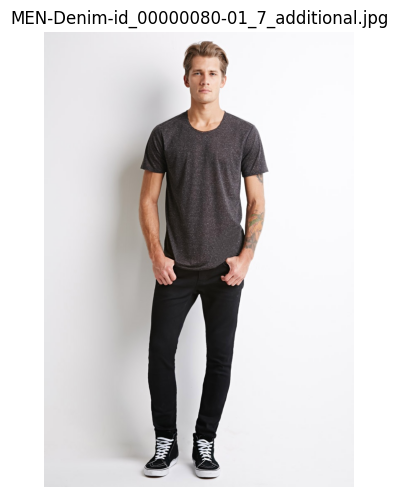

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

sample_image_name = image_files[0]
sample_image_path = Path(IMAGE_DIR) / sample_image_name

img = Image.open(sample_image_path)

print("Filename :", sample_image_name)
print("Format   :", img.format)
print("Size     :", img.size)
print("Mode     :", img.mode)

plt.figure(figsize=(4, 6))
plt.imshow(img)
plt.title(sample_image_name)
plt.axis("off")
plt.show()

In [6]:
import numpy as np

sample_parsing_name = parsing_files[0]
sample_parsing_path = Path(PARSING_DIR) / sample_parsing_name

parsing_img = Image.open(sample_parsing_path)

print("Filename :", sample_parsing_name)
print("Format   :", parsing_img.format)
print("Size     :", parsing_img.size)
print("Mode     :", parsing_img.mode)

mask = np.array(parsing_img)

print()
print("shape :", mask.shape)
print("dtype :", mask.dtype)
print("min   :", mask.min())
print("max   :", mask.max())

unique_values = np.unique(mask)
print("number of unique values:", len(unique_values))
print("unique values:", unique_values)

if mask.ndim == 3:
    print()
    print("Mask có dạng RGB (H, W, 3) -> kiểm tra unique RGB colors")
    flat_pixels = mask.reshape(-1, mask.shape[-1])
    unique_colors = np.unique(flat_pixels, axis=0)
    print("Number of unique RGB colors:", len(unique_colors))
    print(unique_colors)
elif mask.ndim == 2:
    print()
    print("Mask có dạng grayscale/class-ID (H, W) -> unique values ở trên chính là các class ID candidate")

Filename : MEN-Denim-id_00000080-01_7_additional_segm.png
Format   : PNG
Size     : (750, 1101)
Mode     : P

shape : (1101, 750)
dtype : uint8
min   : 0
max   : 15
number of unique values: 7
unique values: [ 0  1  5 11 13 14 15]

Mask có dạng grayscale/class-ID (H, W) -> unique values ở trên chính là các class ID candidate


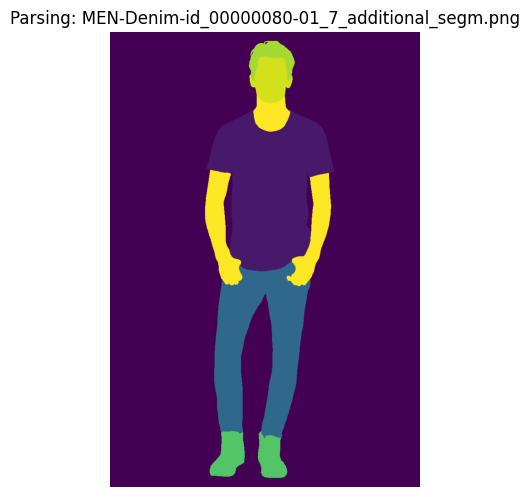

In [7]:
mask_for_display = mask.copy()  # không ghi đè lên biến mask gốc

plt.figure(figsize=(4, 6))
plt.imshow(mask_for_display)
plt.title(f"Parsing: {sample_parsing_name}")
plt.axis("off")
plt.show()

In [8]:
# Bước 1: lấy một số image filenames
sample_images_for_mapping = image_files[:10]


def find_candidate_parsing(image_name, parsing_names):
    image_stem = Path(image_name).stem  # ví dụ: MEN-Denim-id_00000080-01_7_front
    candidates = []
    for p_name in parsing_names:
        parsing_stem = Path(p_name).stem  # ví dụ: MEN-Denim-id_00000080-01_7_additional_segm
        # tìm phần chung ở đầu chuỗi (common prefix)
        common_len = 0
        for a, b in zip(image_stem, parsing_stem):
            if a == b:
                common_len += 1
            else:
                break
        if common_len > 0:
            candidates.append((p_name, common_len))
    candidates.sort(key=lambda x: x[1], reverse=True)
    return candidates

print("=" * 50)
print("KHẢO SÁT MAPPING (chưa kết luận match)")
print("=" * 50)

mapping_results = []

for image_name in sample_images_for_mapping:
    candidates = find_candidate_parsing(image_name, parsing_files)
    best_candidate = candidates[0] if candidates else None

    print()
    print("Image:")
    print(image_name)
    print()
    print("Candidate parsing:")
    if best_candidate:
        print(best_candidate[0], f"(common prefix length = {best_candidate[1]})")
    else:
        print("Không tìm thấy candidate")


    image_stem_len = len(Path(image_name).stem)
    is_match = bool(best_candidate) and (best_candidate[1] / image_stem_len > 0.7)

    print()
    print("Match:")
    print("YES" if is_match else "NO")
    print("-" * 50)

    mapping_results.append({
        "image": image_name,
        "candidate": best_candidate[0] if best_candidate else None,
        "match": is_match
    })

KHẢO SÁT MAPPING (chưa kết luận match)

Image:
MEN-Denim-id_00000080-01_7_additional.jpg

Candidate parsing:
MEN-Denim-id_00000080-01_7_additional_segm.png (common prefix length = 37)

Match:
YES
--------------------------------------------------

Image:
MEN-Denim-id_00000089-01_7_additional.jpg

Candidate parsing:
MEN-Denim-id_00000089-01_7_additional_segm.png (common prefix length = 37)

Match:
YES
--------------------------------------------------

Image:
MEN-Denim-id_00000089-02_7_additional.jpg

Candidate parsing:
MEN-Denim-id_00000089-02_7_additional_segm.png (common prefix length = 37)

Match:
YES
--------------------------------------------------

Image:
MEN-Denim-id_00000089-03_7_additional.jpg

Candidate parsing:
MEN-Denim-id_00000089-03_7_additional_segm.png (common prefix length = 37)

Match:
YES
--------------------------------------------------

Image:
MEN-Denim-id_00000089-04_7_additional.jpg

Candidate parsing:
MEN-Denim-id_00000089-04_7_additional_segm.png (common pref

In [9]:
tested = len(mapping_results)
matched = sum(1 for r in mapping_results if r["match"])
unmatched = tested - matched
match_rate = (matched / tested * 100) if tested > 0 else 0

print("Tested images    :", tested)
print("Matched parsing  :", matched)
print("Unmatched        :", unmatched)
print(f"Match rate       : {match_rate:.0f}%")

if unmatched > 0:
    print()
    print("Unmatched filenames:")
    for r in mapping_results:
        if not r["match"]:
            print("-", r["image"])

Tested images    : 10
Matched parsing  : 10
Unmatched        : 0
Match rate       : 100%


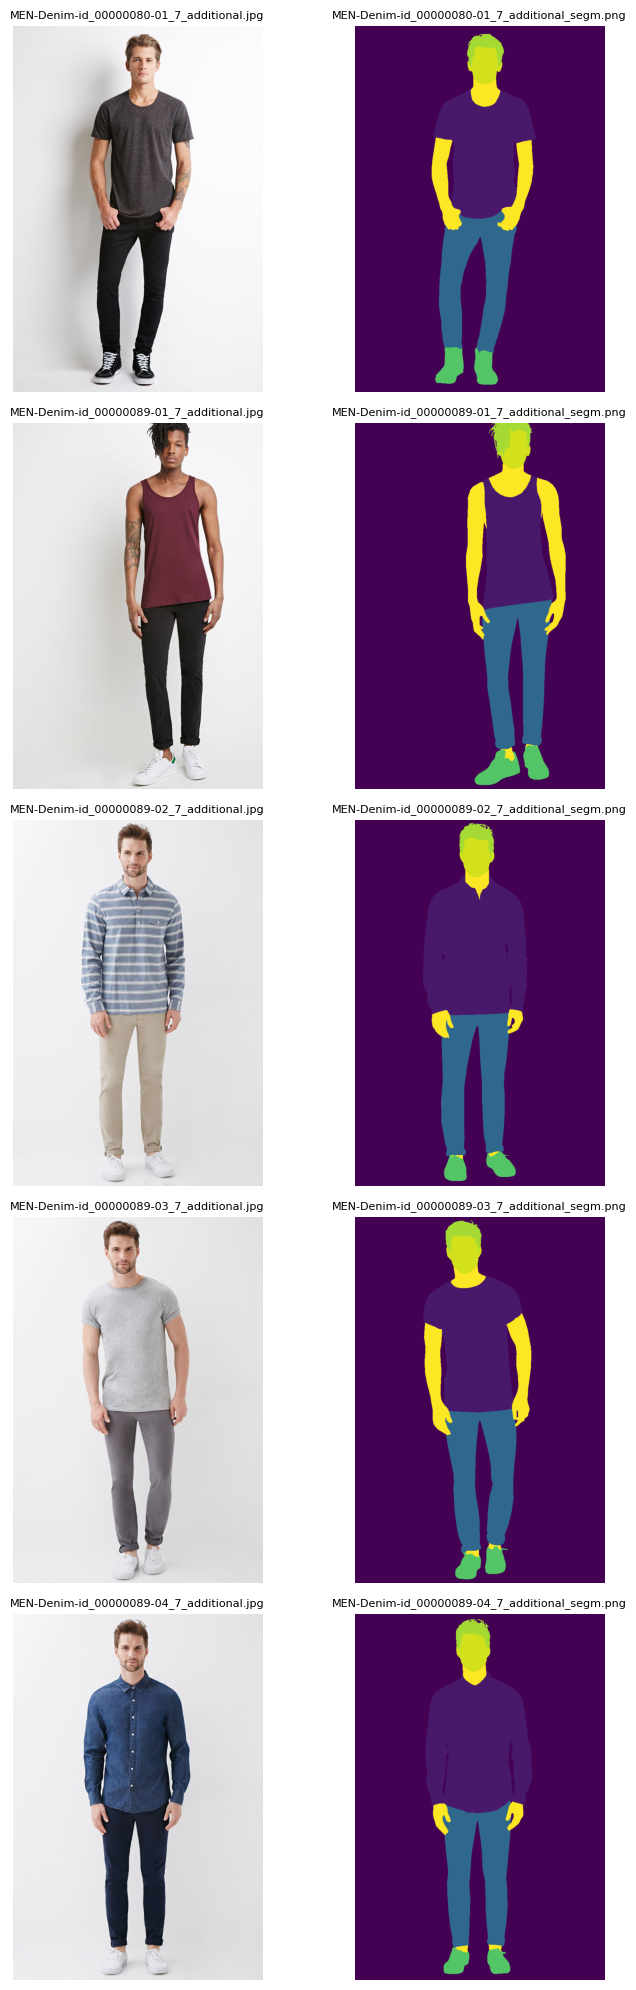

In [10]:
matched_pairs = [r for r in mapping_results if r["match"]][:5]

if not matched_pairs:
    print("Chưa có cặp match nào đủ tin cậy để visualize.")
else:
    fig, axes = plt.subplots(len(matched_pairs), 2, figsize=(8, 4 * len(matched_pairs)))
    if len(matched_pairs) == 1:
        axes = [axes]

    for row, pair in enumerate(matched_pairs):
        img_path = Path(IMAGE_DIR) / pair["image"]
        parsing_path = Path(PARSING_DIR) / pair["candidate"]

        img_display = Image.open(img_path)
        parsing_display = np.array(Image.open(parsing_path))

        axes[row][0].imshow(img_display)
        axes[row][0].set_title(pair["image"], fontsize=8)
        axes[row][0].axis("off")

        axes[row][1].imshow(parsing_display)
        axes[row][1].set_title(pair["candidate"], fontsize=8)
        axes[row][1].axis("off")

    plt.tight_layout()
    plt.show()

In [11]:
print("Các giá trị unique tìm thấy trong parsing sample (Cell 7):")
print(unique_values)

print()
print("Chưa đủ thông tin để xác định semantic class mapping.")

Các giá trị unique tìm thấy trong parsing sample (Cell 7):
[ 0  1  5 11 13 14 15]

Chưa đủ thông tin để xác định semantic class mapping.


In [12]:
print("=" * 40)
print("DEEPFASHION-MULTIMODAL INSPECTION")
print("=" * 40)
print()
print("Images:")
print("    Total:", sum(image_ext_counts.values()))
print()
print("Parsing:")
print("    Total:", sum(parsing_ext_counts.values()))
print()
print("Image format:")
print("   ", img.format)
print()
print("Parsing format:")
print("   ", parsing_img.format)
print()
print("Image size:")
print("   ", img.size)
print()
print("Parsing size:")
print("   ", parsing_img.size)
print()
print("Parsing representation:")
print("   ", "RGB" if mask.ndim == 3 else "Grayscale/Class-ID" if mask.ndim == 2 else "Unknown")
print()
print("Unique values:")
print("   ", unique_values)
print()
print("Image <-> Parsing matching:")
print("    Xem chi tiết ở Cell 9")
print()
print("Match rate:")
print(f"    {match_rate:.0f}%")
print()
print("=" * 40)

DEEPFASHION-MULTIMODAL INSPECTION

Images:
    Total: 44096

Parsing:
    Total: 12701

Image format:
    JPEG

Parsing format:
    PNG

Image size:
    (750, 1101)

Parsing size:
    (750, 1101)

Parsing representation:
    Grayscale/Class-ID

Unique values:
    [ 0  1  5 11 13 14 15]

Image <-> Parsing matching:
    Xem chi tiết ở Cell 9

Match rate:
    100%



In [13]:
from collections import Counter
import numpy as np

mask_array = np.array(mask)

values, counts = np.unique(mask_array, return_counts=True)

for value, count in zip(values, counts):
    percentage = count / mask_array.size * 100
    print(f"Class {value:2d}: {count:8d} pixels ({percentage:6.2f}%)")

Class  0:   639120 pixels ( 77.40%)
Class  1:    75768 pixels (  9.18%)
Class  5:    56757 pixels (  6.87%)
Class 11:    11969 pixels (  1.45%)
Class 13:     4833 pixels (  0.59%)
Class 14:     8013 pixels (  0.97%)
Class 15:    29290 pixels (  3.55%)


In [14]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path

random.seed(42)  # để kết quả có thể tái lập khi debug

CLOTHING_CLASSES = [
    1,   # top
    2,   # outer
    3,   # skirt
    4,   # dress
    5,   # pants
    6,   # leggings
    21,  # rompers
]

PADDING_RATIO = 0.05
N_SAMPLES = 100

In [15]:

image_files_all = sorted([f.name for f in Path(IMAGE_DIR).iterdir() if f.is_file()])
parsing_files_all = sorted([f.name for f in Path(PARSING_DIR).iterdir() if f.is_file()])
parsing_stems_set = set(Path(p).stem for p in parsing_files_all)

def find_matching_parsing(image_name):
    image_stem = Path(image_name).stem
    # theo convention xác nhận ở Phase 1: parsing stem = image_stem + "_segm"
    candidate_stem = image_stem + "_segm"
    if candidate_stem in parsing_stems_set:
        return candidate_stem + ".png"
    return None

valid_pairs = []
for image_name in image_files_all:
    parsing_name = find_matching_parsing(image_name)
    if parsing_name is not None:
        valid_pairs.append((image_name, parsing_name))

print("Tổng số cặp image-parsing hợp lệ tìm được:", len(valid_pairs))

Tổng số cặp image-parsing hợp lệ tìm được: 12701


In [16]:
selected_pairs = random.sample(valid_pairs, N_SAMPLES)

print("10 ẢNH ĐƯỢC CHỌN")
for i, (img_name, parsing_name) in enumerate(selected_pairs, start=1):
    print(f"{i}. image: {img_name}  |  parsing: {parsing_name}")

10 ẢNH ĐƯỢC CHỌN
1. image: WOMEN-Tees_Tanks-id_00001384-03_7_additional.jpg  |  parsing: WOMEN-Tees_Tanks-id_00001384-03_7_additional_segm.png
2. image: WOMEN-Blouses_Shirts-id_00001642-02_1_front.jpg  |  parsing: WOMEN-Blouses_Shirts-id_00001642-02_1_front_segm.png
3. image: MEN-Pants-id_00007948-01_7_additional.jpg  |  parsing: MEN-Pants-id_00007948-01_7_additional_segm.png
4. image: WOMEN-Tees_Tanks-id_00006421-06_4_full.jpg  |  parsing: WOMEN-Tees_Tanks-id_00006421-06_4_full_segm.png
5. image: WOMEN-Dresses-id_00002786-02_3_back.jpg  |  parsing: WOMEN-Dresses-id_00002786-02_3_back_segm.png
6. image: WOMEN-Dresses-id_00001050-02_2_side.jpg  |  parsing: WOMEN-Dresses-id_00001050-02_2_side_segm.png
7. image: WOMEN-Denim-id_00004387-02_1_front.jpg  |  parsing: WOMEN-Denim-id_00004387-02_1_front_segm.png
8. image: WOMEN-Blouses_Shirts-id_00003933-02_7_additional.jpg  |  parsing: WOMEN-Blouses_Shirts-id_00003933-02_7_additional_segm.png
9. image: WOMEN-Tees_Tanks-id_00006103-09_4_full.jp

In [17]:
def create_clothing_mask(parsing_array, clothing_classes):
    return np.isin(parsing_array, clothing_classes)

def compute_bbox(mask):
    """Trả về (min_x, min_y, max_x, max_y) hoặc None nếu mask rỗng."""
    ys, xs = np.where(mask)
    if len(xs) == 0 or len(ys) == 0:
        return None
    min_x, max_x = xs.min(), xs.max()
    min_y, max_y = ys.min(), ys.max()
    return (min_x, min_y, max_x, max_y)

def apply_padding(bbox, image_width, image_height, padding_ratio):
    min_x, min_y, max_x, max_y = bbox
    box_w = max_x - min_x
    box_h = max_y - min_y

    pad_x = int(box_w * padding_ratio)
    pad_y = int(box_h * padding_ratio)

    new_min_x = max(0, min_x - pad_x)
    new_min_y = max(0, min_y - pad_y)
    new_max_x = min(image_width - 1, max_x + pad_x)
    new_max_y = min(image_height - 1, max_y + pad_y)

    return (new_min_x, new_min_y, new_max_x, new_max_y)

In [18]:
results = []

for img_name, parsing_name in selected_pairs:
    img_path = Path(IMAGE_DIR) / img_name
    parsing_path = Path(PARSING_DIR) / parsing_name

    original_img = Image.open(img_path).convert("RGB")
    original_array = np.array(original_img)
    parsing_array = np.array(Image.open(parsing_path))

    clothing_mask = create_clothing_mask(parsing_array, CLOTHING_CLASSES)

    total_pixels = clothing_mask.size
    clothing_pixels = int(clothing_mask.sum())
    clothing_ratio = clothing_pixels / total_pixels * 100

    status = "OK"
    bbox_raw = None
    bbox_padded = None
    cropped_array = None

    if clothing_pixels == 0:
        status = "SKIP_EMPTY_MASK"
    else:
        bbox_raw = compute_bbox(clothing_mask)
        img_h, img_w = clothing_mask.shape
        bbox_padded = apply_padding(bbox_raw, img_w, img_h, PADDING_RATIO)

        min_x, min_y, max_x, max_y = bbox_padded
        if max_x <= min_x or max_y <= min_y:
            status = "INVALID_BBOX"
        else:
            cropped_array = original_array[min_y:max_y+1, min_x:max_x+1]

    results.append({
        "image_name": img_name,
        "parsing_name": parsing_name,
        "original_array": original_array,
        "parsing_array": parsing_array,
        "clothing_mask": clothing_mask,
        "clothing_pixels": clothing_pixels,
        "clothing_ratio": clothing_ratio,
        "bbox_raw": bbox_raw,
        "bbox_padded": bbox_padded,
        "cropped_array": cropped_array,
        "status": status,
    })

    print(f"Image: {img_name}")
    print(f"  Clothing pixels : {clothing_pixels}")
    print(f"  Clothing ratio  : {clothing_ratio:.2f}%")
    print(f"  Bbox (raw)      : {bbox_raw}")
    print(f"  Bbox (padded)   : {bbox_padded}")
    if bbox_padded:
        w = bbox_padded[2] - bbox_padded[0]
        h = bbox_padded[3] - bbox_padded[1]
        print(f"  Crop width      : {w}")
        print(f"  Crop height     : {h}")
    print(f"  Status          : {status}")
    print("-" * 50)

Image: WOMEN-Tees_Tanks-id_00001384-03_7_additional.jpg
  Clothing pixels : 93267
  Clothing ratio  : 11.29%
  Bbox (raw)      : (np.int64(306), np.int64(194), np.int64(503), np.int64(1001))
  Bbox (padded)   : (np.int64(297), np.int64(154), np.int64(512), np.int64(1041))
  Crop width      : 215
  Crop height     : 887
  Status          : OK
--------------------------------------------------
Image: WOMEN-Blouses_Shirts-id_00001642-02_1_front.jpg
  Clothing pixels : 170213
  Clothing ratio  : 20.61%
  Bbox (raw)      : (np.int64(176), np.int64(199), np.int64(559), np.int64(1033))
  Bbox (padded)   : (np.int64(157), np.int64(158), np.int64(578), np.int64(1074))
  Crop width      : 421
  Crop height     : 916
  Status          : OK
--------------------------------------------------
Image: MEN-Pants-id_00007948-01_7_additional.jpg
  Clothing pixels : 140205
  Clothing ratio  : 16.98%
  Bbox (raw)      : (np.int64(310), np.int64(176), np.int64(614), np.int64(981))
  Bbox (padded)   : (np.in

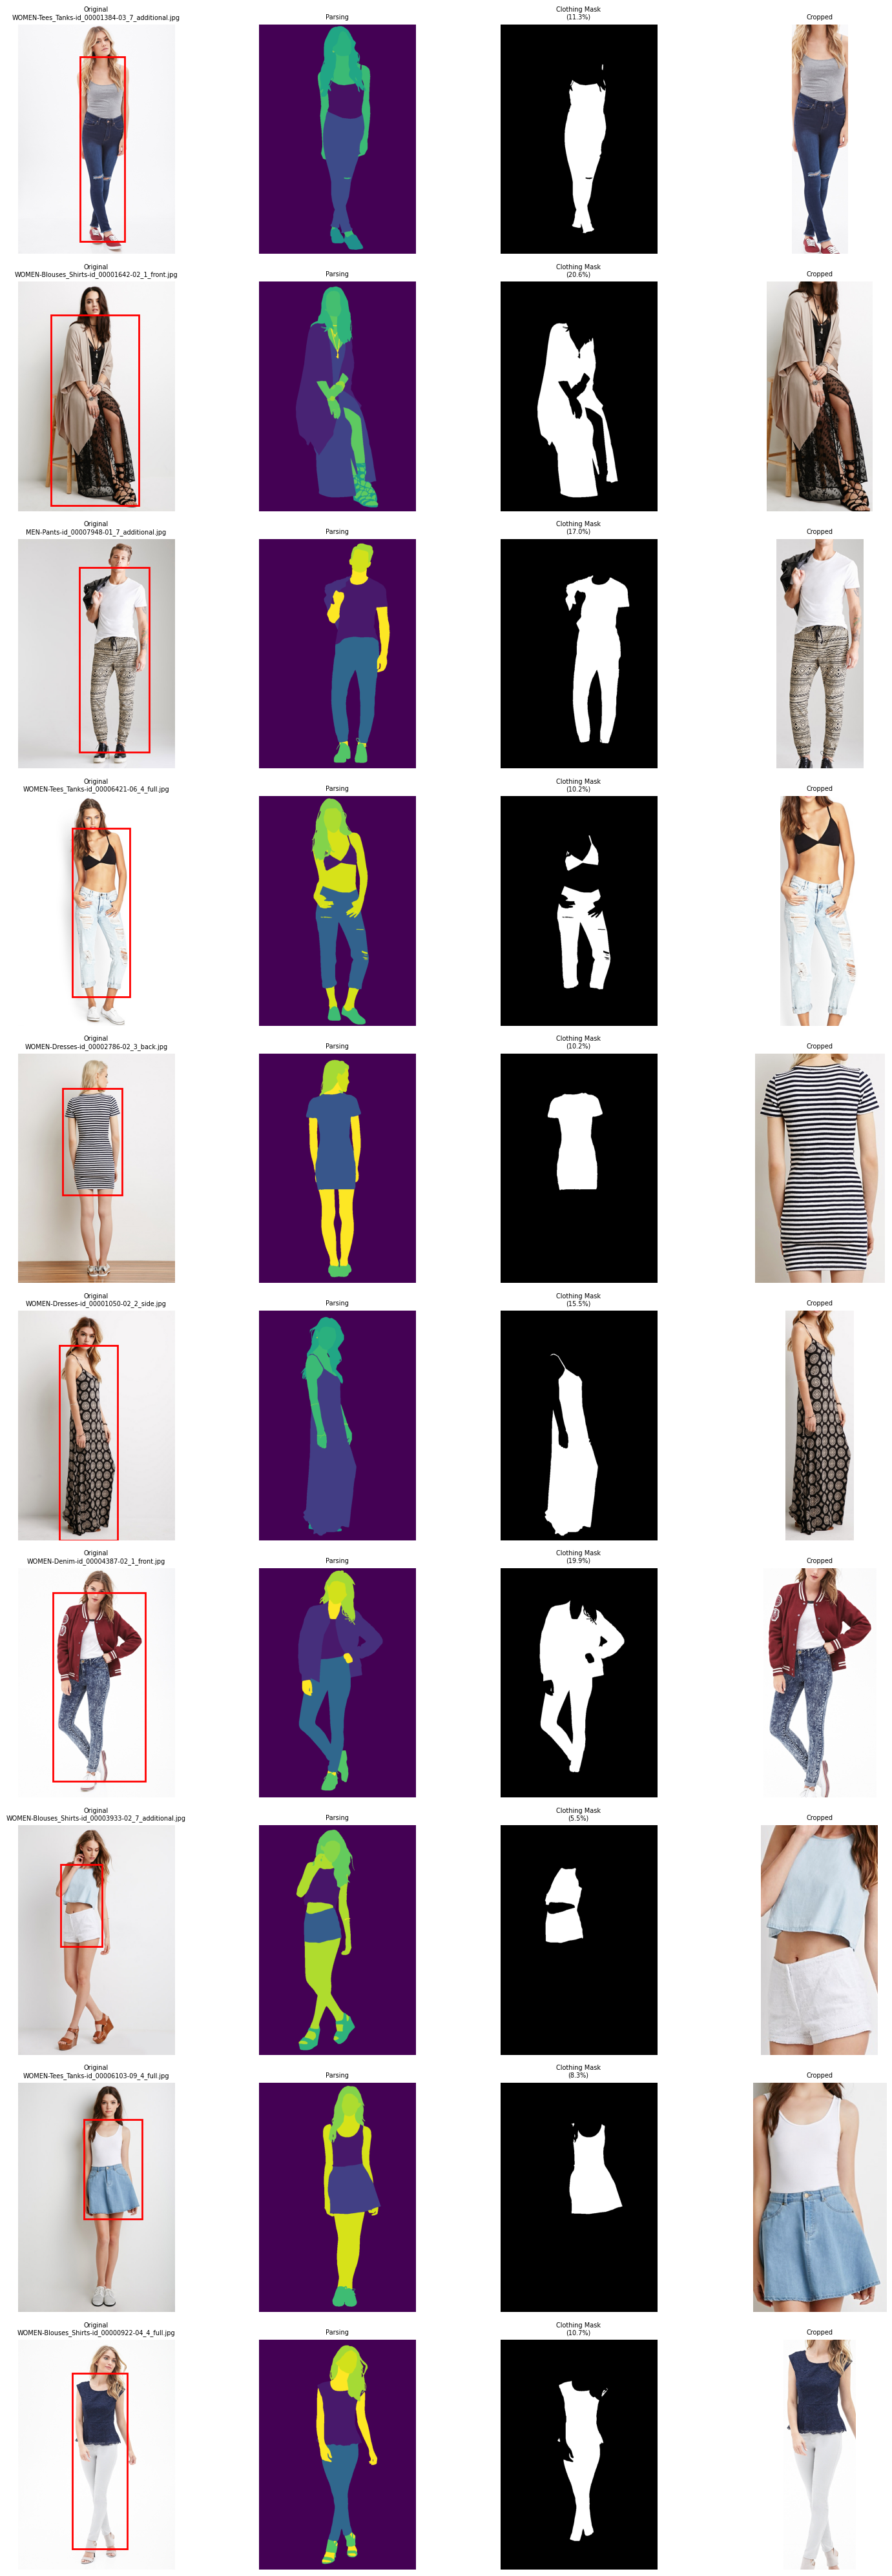

In [19]:
n_display = min(len(results), 10)

fig, axes = plt.subplots(n_display, 4, figsize=(16, 4 * n_display))
if n_display == 1:
    axes = axes.reshape(1, -1)

for row, r in enumerate(results[:n_display]):
    # Panel 1: Original + bbox
    axes[row][0].imshow(r["original_array"])
    if r["bbox_padded"]:
        min_x, min_y, max_x, max_y = r["bbox_padded"]
        rect = patches.Rectangle(
            (min_x, min_y), max_x - min_x, max_y - min_y,
            linewidth=2, edgecolor="red", facecolor="none"
        )
        axes[row][0].add_patch(rect)
    axes[row][0].set_title(f"Original\n{r['image_name']}", fontsize=7)
    axes[row][0].axis("off")

    # Panel 2: Parsing
    axes[row][1].imshow(r["parsing_array"])
    axes[row][1].set_title("Parsing", fontsize=7)
    axes[row][1].axis("off")

    # Panel 3: Clothing mask
    axes[row][2].imshow(r["clothing_mask"], cmap="gray")
    axes[row][2].set_title(f"Clothing Mask\n({r['clothing_ratio']:.1f}%)", fontsize=7)
    axes[row][2].axis("off")

    # Panel 4: Cropped image
    if r["cropped_array"] is not None:
        axes[row][3].imshow(r["cropped_array"])
        axes[row][3].set_title("Cropped", fontsize=7)
    else:
        axes[row][3].text(0.5, 0.5, r["status"], ha="center", va="center")
    axes[row][3].axis("off")

plt.tight_layout()
plt.show()

In [20]:
total_samples = len(results)
successful_crops = sum(1 for r in results if r["status"] == "OK")
empty_masks = sum(1 for r in results if r["status"] == "SKIP_EMPTY_MASK")
invalid_bbox = sum(1 for r in results if r["status"] == "INVALID_BBOX")

clothing_ratios = [r["clothing_ratio"] for r in results if r["status"] == "OK"]

mean_area = np.mean(clothing_ratios) if clothing_ratios else 0
min_area = np.min(clothing_ratios) if clothing_ratios else 0
max_area = np.max(clothing_ratios) if clothing_ratios else 0

print("=" * 37)
print("PHASE 2 – CLOTHING CROP TEST")
print("=" * 37)
print()
print("Total samples      :", total_samples)
print("Successful crops   :", successful_crops)
print("Empty masks        :", empty_masks)
print("Invalid bbox       :", invalid_bbox)
print()
print(f"Mean clothing area : {mean_area:.2f} %")
print(f"Min clothing area  : {min_area:.2f} %")
print(f"Max clothing area  : {max_area:.2f} %")
print()
print("=" * 37)

PHASE 2 – CLOTHING CROP TEST

Total samples      : 100
Successful crops   : 100
Empty masks        : 0
Invalid bbox       : 0

Mean clothing area : 13.04 %
Min clothing area  : 4.63 %
Max clothing area  : 38.71 %



In [21]:
!pip install -q transformers torch pillow numpy

In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [23]:
MODEL_NAME = "patrickjohncyh/fashion-clip"  # Fashion-CLIP chính thức trên HuggingFace
N_SAMPLES = 100

In [24]:
def load_model(model_name, device):
    model = CLIPModel.from_pretrained(model_name)
    processor = CLIPProcessor.from_pretrained(model_name)
    model.to(device)
    model.eval()
    return model, processor

model, processor = load_model(MODEL_NAME, device)

print("Model loaded:", MODEL_NAME)
print("Image processor config:")
print(processor.image_processor)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Model loaded: patrickjohncyh/fashion-clip
Image processor config:
CLIPImageProcessorFast {
  "crop_size": {
    "height": 224,
    "width": 224
  },
  "data_format": "channels_first",
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.48145466,
    0.4578275,
    0.40821073
  ],
  "image_processor_type": "CLIPImageProcessorFast",
  "image_std": [
    0.26862954,
    0.26130258,
    0.27577711
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 224
  }
}



In [25]:
def load_images(image_dir, parsing_dir, clothing_classes, padding_ratio, n_samples, seed=42):
    """
    Tái sử dụng logic mapping + crop đã confirm ở Phase 1/2.
    Trả về list dict: {image_id, image_path, crop_path(placeholder), original_pil, cropped_pil}
    """
    import random
    random.seed(seed)

    image_files_all = sorted([f.name for f in Path(image_dir).iterdir() if f.is_file()])
    parsing_files_all = sorted([f.name for f in Path(parsing_dir).iterdir() if f.is_file()])
    parsing_stems_set = set(Path(p).stem for p in parsing_files_all)

    def find_matching_parsing(image_name):
        candidate_stem = Path(image_name).stem + "_segm"
        if candidate_stem in parsing_stems_set:
            return candidate_stem + ".png"
        return None

    valid_pairs = []
    for image_name in image_files_all:
        parsing_name = find_matching_parsing(image_name)
        if parsing_name is not None:
            valid_pairs.append((image_name, parsing_name))

    selected_pairs = random.sample(valid_pairs, n_samples)

    def compute_bbox(mask):
        ys, xs = np.where(mask)
        if len(xs) == 0:
            return None
        return (xs.min(), ys.min(), xs.max(), ys.max())

    def apply_padding(bbox, w, h, ratio):
        min_x, min_y, max_x, max_y = bbox
        pad_x = int((max_x - min_x) * ratio)
        pad_y = int((max_y - min_y) * ratio)
        return (
            max(0, min_x - pad_x),
            max(0, min_y - pad_y),
            min(w - 1, max_x + pad_x),
            min(h - 1, max_y + pad_y),
        )

    samples = []
    for img_name, parsing_name in selected_pairs:
        img_path = Path(image_dir) / img_name
        parsing_path = Path(parsing_dir) / parsing_name

        original_pil = Image.open(img_path).convert("RGB")
        original_array = np.array(original_pil)
        parsing_array = np.array(Image.open(parsing_path))

        clothing_mask = np.isin(parsing_array, clothing_classes)
        bbox = compute_bbox(clothing_mask)

        if bbox is None:
            print(f"[WARNING] Empty clothing mask, skip: {img_name}")
            continue

        h, w = clothing_mask.shape
        min_x, min_y, max_x, max_y = apply_padding(bbox, w, h, padding_ratio)
        cropped_array = original_array[min_y:max_y+1, min_x:max_x+1]
        cropped_pil = Image.fromarray(cropped_array)

        samples.append({
            "image_id": Path(img_name).stem,
            "image_path": str(img_path),
            "original_pil": original_pil,
            "cropped_pil": cropped_pil,
        })

    return samples

CLOTHING_CLASSES = [1, 2, 3, 4, 5, 6, 21]
PADDING_RATIO = 0.05

samples = load_images(IMAGE_DIR, PARSING_DIR, CLOTHING_CLASSES, PADDING_RATIO, N_SAMPLES)

print(f"Loaded {len(samples)} samples")
for s in samples:
    print("-", s["image_id"])

Loaded 100 samples
- WOMEN-Tees_Tanks-id_00001384-03_7_additional
- WOMEN-Blouses_Shirts-id_00001642-02_1_front
- MEN-Pants-id_00007948-01_7_additional
- WOMEN-Tees_Tanks-id_00006421-06_4_full
- WOMEN-Dresses-id_00002786-02_3_back
- WOMEN-Dresses-id_00001050-02_2_side
- WOMEN-Denim-id_00004387-02_1_front
- WOMEN-Blouses_Shirts-id_00003933-02_7_additional
- WOMEN-Tees_Tanks-id_00006103-09_4_full
- WOMEN-Blouses_Shirts-id_00000922-04_4_full
- WOMEN-Tees_Tanks-id_00003343-19_7_additional
- WOMEN-Tees_Tanks-id_00006366-03_2_side
- WOMEN-Skirts-id_00003518-01_3_back
- MEN-Tees_Tanks-id_00006930-01_7_additional
- WOMEN-Sweaters-id_00004861-04_4_full
- WOMEN-Jackets_Coats-id_00007157-02_2_side
- MEN-Shirts_Polos-id_00005557-08_7_additional
- MEN-Shirts_Polos-id_00004194-01_4_full
- WOMEN-Blouses_Shirts-id_00000132-04_4_full
- WOMEN-Cardigans-id_00007543-06_7_additional
- WOMEN-Dresses-id_00000388-07_2_side
- WOMEN-Shorts-id_00000543-06_4_full
- WOMEN-Sweaters-id_00007221-14_1_front
- MEN-Shir

In [26]:
def extract_embeddings(model, processor, samples, device):
    """
    Trả về: original_embeddings (list tensor), cropped_embeddings (list tensor),
             successful_ids, failed (list dict {image_path, error})
    """
    original_embeddings = []
    cropped_embeddings = []
    successful_ids = []
    failed = []

    def get_embedding_tensor(output):
        """
        Chuẩn hóa output của get_image_features về tensor thuần,
        bất kể model trả về Tensor hay BaseModelOutputWithPooling.
        """
        if isinstance(output, torch.Tensor):
            return output
        if hasattr(output, "image_embeds"):
            return output.image_embeds
        if hasattr(output, "pooler_output"):
            return output.pooler_output
        raise TypeError(f"Không xác định được embedding tensor từ output type: {type(output)}")

    with torch.no_grad():
        for s in samples:
            try:
                inputs_orig = processor(images=s["original_pil"], return_tensors="pt").to(device)
                raw_orig = model.get_image_features(**inputs_orig)
                emb_orig = get_embedding_tensor(raw_orig)

                inputs_crop = processor(images=s["cropped_pil"], return_tensors="pt").to(device)
                raw_crop = model.get_image_features(**inputs_crop)
                emb_crop = get_embedding_tensor(raw_crop)

                original_embeddings.append(emb_orig.squeeze(0).cpu())
                cropped_embeddings.append(emb_crop.squeeze(0).cpu())
                successful_ids.append(s["image_id"])

            except Exception as e:
                failed.append({"image_path": s["image_path"], "error": str(e)})
                print(f"[ERROR] {s['image_path']}: {e}")

    original_embeddings = torch.stack(original_embeddings) if original_embeddings else torch.empty(0)
    cropped_embeddings = torch.stack(cropped_embeddings) if cropped_embeddings else torch.empty(0)

    return original_embeddings, cropped_embeddings, successful_ids, failed


original_embeddings, cropped_embeddings, successful_ids, failed = extract_embeddings(
    model, processor, samples, device
)

print("Original embedding shape:", original_embeddings.shape)
print("Cropped embedding shape :", cropped_embeddings.shape)
print("Successful:", len(successful_ids))
print("Failed    :", len(failed))

Original embedding shape: torch.Size([100, 512])
Cropped embedding shape : torch.Size([100, 512])
Successful: 100
Failed    : 0


In [27]:
def validate_embeddings(embeddings, name):
    print(f"--- {name} ---")
    print("Shape :", embeddings.shape)
    print("Dtype :", embeddings.dtype)

    has_nan = torch.isnan(embeddings).any().item()
    has_inf = torch.isinf(embeddings).any().item()
    print("NaN present:", has_nan)
    print("Inf present:", has_inf)

    norms_before = torch.norm(embeddings, dim=-1)
    print("Norm before normalization (mean):", norms_before.mean().item())

    if has_nan or has_inf:
        raise ValueError(f"{name} chứa NaN hoặc Inf — dừng lại và kiểm tra lỗi trước khi tiếp tục.")

    return norms_before

orig_norms_before = validate_embeddings(original_embeddings, "Original Embeddings")
crop_norms_before = validate_embeddings(cropped_embeddings, "Cropped Embeddings")

--- Original Embeddings ---
Shape : torch.Size([100, 512])
Dtype : torch.float32
NaN present: False
Inf present: False
Norm before normalization (mean): 10.481819152832031
--- Cropped Embeddings ---
Shape : torch.Size([100, 512])
Dtype : torch.float32
NaN present: False
Inf present: False
Norm before normalization (mean): 10.905987739562988


In [28]:
def normalize_embeddings(embeddings):
    return embeddings / embeddings.norm(dim=-1, keepdim=True)

original_embeddings_norm = normalize_embeddings(original_embeddings)
cropped_embeddings_norm = normalize_embeddings(cropped_embeddings)

orig_norms_after = torch.norm(original_embeddings_norm, dim=-1)
crop_norms_after = torch.norm(cropped_embeddings_norm, dim=-1)

print("Original norm after normalization (mean):", orig_norms_after.mean().item())
print("Cropped norm after normalization (mean):", crop_norms_after.mean().item())

Original norm after normalization (mean): 1.0
Cropped norm after normalization (mean): 1.0


In [29]:
def cosine_similarity(a, b):
    return torch.nn.functional.cosine_similarity(a, b, dim=-1)

similarities = cosine_similarity(original_embeddings_norm, cropped_embeddings_norm)

for i, (img_id, sim) in enumerate(zip(successful_ids, similarities), start=1):
    print(f"Image {i} ({img_id}): similarity = {sim.item():.4f}")

mean_sim = similarities.mean().item()
min_sim = similarities.min().item()
max_sim = similarities.max().item()

Image 1 (WOMEN-Tees_Tanks-id_00001384-03_7_additional): similarity = 0.7153
Image 2 (WOMEN-Blouses_Shirts-id_00001642-02_1_front): similarity = 0.9075
Image 3 (MEN-Pants-id_00007948-01_7_additional): similarity = 0.8030
Image 4 (WOMEN-Tees_Tanks-id_00006421-06_4_full): similarity = 0.7630
Image 5 (WOMEN-Dresses-id_00002786-02_3_back): similarity = 0.8785
Image 6 (WOMEN-Dresses-id_00001050-02_2_side): similarity = 0.7300
Image 7 (WOMEN-Denim-id_00004387-02_1_front): similarity = 0.8690
Image 8 (WOMEN-Blouses_Shirts-id_00003933-02_7_additional): similarity = 0.8068
Image 9 (WOMEN-Tees_Tanks-id_00006103-09_4_full): similarity = 0.7816
Image 10 (WOMEN-Blouses_Shirts-id_00000922-04_4_full): similarity = 0.7709
Image 11 (WOMEN-Tees_Tanks-id_00003343-19_7_additional): similarity = 0.6658
Image 12 (WOMEN-Tees_Tanks-id_00006366-03_2_side): similarity = 0.8834
Image 13 (WOMEN-Skirts-id_00003518-01_3_back): similarity = 0.8511
Image 14 (MEN-Tees_Tanks-id_00006930-01_7_additional): similarity = 0.

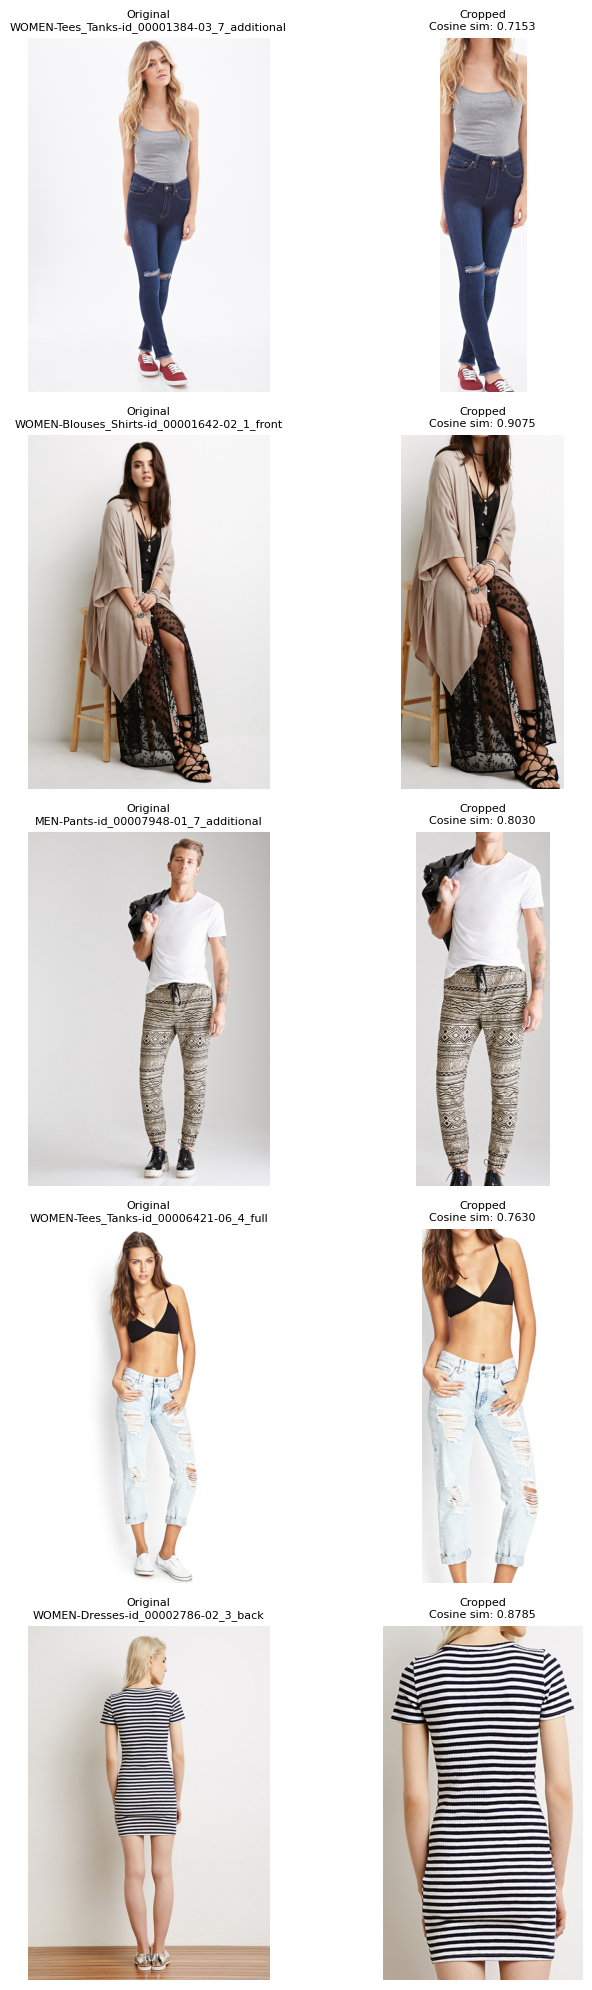

In [30]:
n_display = min(len(samples), 5)

fig, axes = plt.subplots(n_display, 2, figsize=(8, 4 * n_display))
if n_display == 1:
    axes = axes.reshape(1, -1)

for row in range(n_display):
    s = samples[row]
    sim = similarities[row].item()

    axes[row][0].imshow(s["original_pil"])
    axes[row][0].set_title(f"Original\n{s['image_id']}", fontsize=8)
    axes[row][0].axis("off")

    axes[row][1].imshow(s["cropped_pil"])
    axes[row][1].set_title(f"Cropped\nCosine sim: {sim:.4f}", fontsize=8)
    axes[row][1].axis("off")

plt.tight_layout()
plt.show()

In [31]:
def save_embeddings(original_embeddings, cropped_embeddings, image_ids, output_dir):
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    np.save(output_path / "original_embeddings_step1.npy", original_embeddings.numpy())
    np.save(output_path / "cropped_embeddings_step1.npy", cropped_embeddings.numpy())
    np.save(output_path / "image_ids_step1.npy", np.array(image_ids))

    print("Saved to:", output_path)



In [32]:
print("=" * 40)
print("PHASE 3 – FASHION-CLIP EMBEDDING TEST")
print("=" * 40)
print()
print("Device:", device)
print("Model :", MODEL_NAME)
print()
print("Number of samples:", len(samples))
print()
print("Original embedding shape:", original_embeddings.shape)
print("Cropped embedding shape :", cropped_embeddings.shape)
print()
print("Embedding dtype:", original_embeddings.dtype)
print()
print("NaN:", torch.isnan(original_embeddings).any().item() or torch.isnan(cropped_embeddings).any().item())
print("Inf:", torch.isinf(original_embeddings).any().item() or torch.isinf(cropped_embeddings).any().item())
print()
print("Original norm before normalization:", orig_norms_before.mean().item())
print("Original norm after normalization :", orig_norms_after.mean().item())
print()
print("Cropped norm before normalization:", crop_norms_before.mean().item())
print("Cropped norm after normalization :", crop_norms_after.mean().item())
print()
print("Mean cosine similarity:", mean_sim)
print("Min cosine similarity :", min_sim)
print("Max cosine similarity :", max_sim)
print()
print("Successful embeddings:", len(successful_ids))
print("Failed embeddings    :", len(failed))
if failed:
    print()
    print("Failed details:")
    for f in failed:
        print(f"  path: {f['image_path']}  error: {f['error']}")
print()
print("=" * 40)

PHASE 3 – FASHION-CLIP EMBEDDING TEST

Device: cuda
Model : patrickjohncyh/fashion-clip

Number of samples: 100

Original embedding shape: torch.Size([100, 512])
Cropped embedding shape : torch.Size([100, 512])

Embedding dtype: torch.float32

NaN: False
Inf: False

Original norm before normalization: 10.481819152832031
Original norm after normalization : 1.0

Cropped norm before normalization: 10.905987739562988
Cropped norm after normalization : 1.0

Mean cosine similarity: 0.8105345368385315
Min cosine similarity : 0.6657897233963013
Max cosine similarity : 0.9564626216888428

Successful embeddings: 100
Failed embeddings    : 0



In [33]:
import time
import traceback
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

CLOTHING_CLASSES = [1, 2, 3, 4, 5, 6, 21]
PADDING_RATIO = 0.05
BATCH_SIZE = 16  # sẽ giảm xuống 8 → 4 nếu OOM

OUTPUT_DIR = Path("/kaggle/working/data/processed/embeddings")
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("Output dir     :", OUTPUT_DIR)
print("Checkpoint dir :", CHECKPOINT_DIR)
print("Batch size     :", BATCH_SIZE)

Output dir     : /kaggle/working/data/processed/embeddings
Checkpoint dir : /kaggle/working/data/processed/embeddings/checkpoints
Batch size     : 16


In [34]:
def build_valid_pairs(image_dir, parsing_dir):
    image_files_all = sorted([f.name for f in Path(image_dir).iterdir() if f.is_file()])
    parsing_files_all = sorted([f.name for f in Path(parsing_dir).iterdir() if f.is_file()])
    parsing_stems_set = set(Path(p).stem for p in parsing_files_all)

    valid_pairs = []
    missing_parsing = 0

    for image_name in image_files_all:
        candidate_stem = Path(image_name).stem + "_segm"
        if candidate_stem in parsing_stems_set:
            valid_pairs.append((image_name, candidate_stem + ".png"))
        else:
            missing_parsing += 1

    return valid_pairs, len(image_files_all), missing_parsing

valid_pairs, total_images, missing_parsing = build_valid_pairs(IMAGE_DIR, PARSING_DIR)

print("=" * 40)
print("FULL DATASET CHECK")
print("=" * 40)
print()
print("Total images scanned      :", total_images)
print("Valid image-parsing pairs :", len(valid_pairs))
print("Missing parsing           :", missing_parsing)
print()
print("=" * 40)

EXPECTED_COUNT = 12701
if len(valid_pairs) != EXPECTED_COUNT:
    print(f"[CẢNH BÁO] Số valid pairs ({len(valid_pairs)}) khác với kỳ vọng ({EXPECTED_COUNT}).")
    print("Không tự động tiếp tục — hãy kiểm tra nguyên nhân trước khi chạy full extraction.")
else:
    print("Số lượng khớp với kỳ vọng. Có thể tiếp tục.")

FULL DATASET CHECK

Total images scanned      : 44096
Valid image-parsing pairs : 12701
Missing parsing           : 31395

Số lượng khớp với kỳ vọng. Có thể tiếp tục.


In [35]:
def compute_bbox(mask):
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None
    return (xs.min(), ys.min(), xs.max(), ys.max())

def apply_padding(bbox, w, h, ratio):
    min_x, min_y, max_x, max_y = bbox
    pad_x = int((max_x - min_x) * ratio)
    pad_y = int((max_y - min_y) * ratio)
    return (
        max(0, min_x - pad_x),
        max(0, min_y - pad_y),
        min(w - 1, max_x + pad_x),
        min(h - 1, max_y + pad_y),
    )

def load_image_and_crop(image_path, parsing_path, clothing_classes, padding_ratio):
    """
    Trả về (original_pil, cropped_pil). Raise Exception nếu có lỗi
    (empty mask, invalid bbox, file lỗi, v.v.) để caller xử lý.
    """
    original_pil = Image.open(image_path).convert("RGB")
    original_array = np.array(original_pil)
    parsing_array = np.array(Image.open(parsing_path))

    clothing_mask = np.isin(parsing_array, clothing_classes)
    bbox = compute_bbox(clothing_mask)

    if bbox is None:
        raise ValueError("Empty clothing mask")

    h, w = clothing_mask.shape
    min_x, min_y, max_x, max_y = apply_padding(bbox, w, h, padding_ratio)

    if max_x <= min_x or max_y <= min_y:
        raise ValueError("Invalid bbox after padding")

    cropped_array = original_array[min_y:max_y+1, min_x:max_x+1]
    cropped_pil = Image.fromarray(cropped_array)

    return original_pil, cropped_pil

In [36]:
def get_embedding_tensor(output):
    if isinstance(output, torch.Tensor):
        return output
    if hasattr(output, "image_embeds"):
        return output.image_embeds
    if hasattr(output, "pooler_output"):
        return output.pooler_output
    raise TypeError(f"Không xác định được embedding tensor từ output type: {type(output)}")

In [37]:
def extract_full_dataset(
    model, processor, valid_pairs, image_dir, parsing_dir,
    clothing_classes, padding_ratio, batch_size, device,
    checkpoint_dir
):
    model.eval()

    successful_records = []   # list of dict: image_id, image_path, crop_index
    failed_samples = []       # list of dict: image_id, image_path, error

    n_total = len(valid_pairs)
    n_batches = (n_total + batch_size - 1) // batch_size

    start_time = time.time()

    pbar = tqdm(total=n_total, desc="Extracting embeddings")

    for batch_idx in range(n_batches):
        batch_pairs = valid_pairs[batch_idx * batch_size : (batch_idx + 1) * batch_size]

        batch_originals = []
        batch_crops = []
        batch_meta = []  # (image_id, image_path)

        for image_name, parsing_name in batch_pairs:
            image_path = Path(image_dir) / image_name
            parsing_path = Path(parsing_dir) / parsing_name
            image_id = Path(image_name).stem

            try:
                original_pil, cropped_pil = load_image_and_crop(
                    image_path, parsing_path, clothing_classes, padding_ratio
                )
                batch_originals.append(original_pil)
                batch_crops.append(cropped_pil)
                batch_meta.append((image_id, str(image_path)))
            except Exception as e:
                failed_samples.append({
                    "image_id": image_id,
                    "image_path": str(image_path),
                    "error": str(e),
                })

        if len(batch_originals) == 0:
            pbar.update(len(batch_pairs))
            continue

        try:
            with torch.no_grad():
                inputs_orig = processor(images=batch_originals, return_tensors="pt").to(device)
                raw_orig = model.get_image_features(**inputs_orig)
                emb_orig = get_embedding_tensor(raw_orig).cpu()

                inputs_crop = processor(images=batch_crops, return_tensors="pt").to(device)
                raw_crop = model.get_image_features(**inputs_crop)
                emb_crop = get_embedding_tensor(raw_crop).cpu()

            checkpoint_path = checkpoint_dir / f"checkpoint_{batch_idx:05d}.npz"
            np.savez(
                checkpoint_path,
                original=emb_orig.numpy(),
                cropped=emb_crop.numpy(),
                image_ids=np.array([m[0] for m in batch_meta]),
                image_paths=np.array([m[1] for m in batch_meta]),
            )

            for image_id, image_path in batch_meta:
                successful_records.append({"image_id": image_id, "image_path": image_path})

        except torch.cuda.OutOfMemoryError as e:
            # Ghi lỗi cho cả batch này, không crash toàn bộ pipeline
            torch.cuda.empty_cache()
            for image_id, image_path in batch_meta:
                failed_samples.append({
                    "image_id": image_id,
                    "image_path": image_path,
                    "error": f"CUDA OOM at batch_size={batch_size}: {str(e)}",
                })
            print(f"[OOM] Batch {batch_idx} thất bại với batch_size={batch_size}. "
                  f"Hãy giảm BATCH_SIZE (16→8→4) và chạy lại từ batch này.")
        except Exception as e:
            for image_id, image_path in batch_meta:
                failed_samples.append({
                    "image_id": image_id,
                    "image_path": image_path,
                    "error": str(e),
                })
            print(f"[ERROR] Batch {batch_idx}: {e}")
            traceback.print_exc()

        pbar.update(len(batch_pairs))

        elapsed = time.time() - start_time
        processed = pbar.n
        rate = processed / elapsed if elapsed > 0 else 0
        pbar.set_postfix({"img/s": f"{rate:.2f}"})

    pbar.close()
    total_time = time.time() - start_time

    return successful_records, failed_samples, total_time, n_batches

successful_records, failed_samples, total_time, n_batches = extract_full_dataset(
    model, processor, valid_pairs, IMAGE_DIR, PARSING_DIR,
    CLOTHING_CLASSES, PADDING_RATIO, BATCH_SIZE, device,
    CHECKPOINT_DIR
)

print()
print("Extraction hoàn tất.")
print("Successful:", len(successful_records))
print("Failed    :", len(failed_samples))
print(f"Total time: {total_time:.2f}s")

Extracting embeddings:   0%|          | 0/12701 [00:00<?, ?it/s]


Extraction hoàn tất.
Successful: 12701
Failed    : 0
Total time: 517.69s


In [38]:
def merge_checkpoints(checkpoint_dir, n_batches):
    all_original = []
    all_cropped = []
    all_image_ids = []
    all_image_paths = []

    checkpoint_files = sorted(checkpoint_dir.glob("checkpoint_*.npz"))

    for cp_path in checkpoint_files:
        data = np.load(cp_path, allow_pickle=True)
        all_original.append(data["original"])
        all_cropped.append(data["cropped"])
        all_image_ids.append(data["image_ids"])
        all_image_paths.append(data["image_paths"])

    original_embeddings = np.concatenate(all_original, axis=0)
    cropped_embeddings = np.concatenate(all_cropped, axis=0)
    image_ids = np.concatenate(all_image_ids, axis=0)
    image_paths = np.concatenate(all_image_paths, axis=0)

    return original_embeddings, cropped_embeddings, image_ids, image_paths

original_embeddings_np, cropped_embeddings_np, image_ids, image_paths = merge_checkpoints(
    CHECKPOINT_DIR, n_batches
)

print("Merged original embeddings:", original_embeddings_np.shape)
print("Merged cropped embeddings :", cropped_embeddings_np.shape)
print("Number of image_ids       :", len(image_ids))

# Kiểm tra thứ tự metadata <-> embeddings khớp nhau
assert len(image_ids) == original_embeddings_np.shape[0] == cropped_embeddings_np.shape[0], \
    "Số lượng image_ids và embeddings không khớp — dừng lại kiểm tra."

Merged original embeddings: (12701, 512)
Merged cropped embeddings : (12701, 512)
Number of image_ids       : 12701


In [39]:
def normalize_embeddings_np(embeddings):
    norms = np.linalg.norm(embeddings, axis=-1, keepdims=True)
    return embeddings / norms

original_norms_before = np.linalg.norm(original_embeddings_np, axis=-1)
cropped_norms_before = np.linalg.norm(cropped_embeddings_np, axis=-1)

original_embeddings_norm = normalize_embeddings_np(original_embeddings_np)
cropped_embeddings_norm = normalize_embeddings_np(cropped_embeddings_np)

original_norms_after = np.linalg.norm(original_embeddings_norm, axis=-1)
cropped_norms_after = np.linalg.norm(cropped_embeddings_norm, axis=-1)

print("Original norm before -> mean:", original_norms_before.mean())
print("Original norm after  -> mean:", original_norms_after.mean())
print("Cropped norm before  -> mean:", cropped_norms_before.mean())
print("Cropped norm after   -> mean:", cropped_norms_after.mean())

Original norm before -> mean: 10.468428
Original norm after  -> mean: 1.0
Cropped norm before  -> mean: 10.9161
Cropped norm after   -> mean: 1.0


In [40]:
def validate_full(embeddings, name):
    has_nan = np.isnan(embeddings).any()
    has_inf = np.isinf(embeddings).any()
    print(f"{name} — NaN: {has_nan}, Inf: {has_inf}")
    if has_nan or has_inf:
        raise ValueError(f"{name} chứa NaN hoặc Inf — dừng lại và kiểm tra trước khi lưu.")

validate_full(original_embeddings_norm, "Original Embeddings")
validate_full(cropped_embeddings_norm, "Cropped Embeddings")

Original Embeddings — NaN: False, Inf: False
Cropped Embeddings — NaN: False, Inf: False


In [41]:
def cosine_similarity_np(a, b):
    return np.sum(a * b, axis=-1)  # đã normalize nên dot product = cosine similarity

full_similarities = cosine_similarity_np(original_embeddings_norm, cropped_embeddings_norm)

sim_mean = full_similarities.mean()
sim_median = np.median(full_similarities)
sim_min = full_similarities.min()
sim_max = full_similarities.max()
sim_std = full_similarities.std()

print("Mean similarity  :", sim_mean)
print("Median similarity:", sim_median)
print("Min similarity   :", sim_min)
print("Max similarity   :", sim_max)
print("Std similarity   :", sim_std)

Mean similarity  : 0.79894245
Median similarity: 0.8048926
Min similarity   : 0.44638282
Max similarity   : 0.9846754
Std similarity   : 0.059038535


In [42]:
def save_full_outputs(output_dir, original_embeddings, cropped_embeddings,
                       image_ids, image_paths, failed_samples):
    output_dir = Path(output_dir)

    np.save(output_dir / "original_embeddings.npy", original_embeddings)
    np.save(output_dir / "cropped_embeddings.npy", cropped_embeddings)

    metadata_df = pd.DataFrame({
        "image_id": image_ids,
        "image_path": image_paths,
    })
    metadata_df.to_csv(output_dir / "metadata.csv", index=False)

    if failed_samples:
        failed_df = pd.DataFrame(failed_samples)
    else:
        failed_df = pd.DataFrame(columns=["image_id", "image_path", "error"])
    failed_df.to_csv(output_dir / "failed_samples.csv", index=False)

    print("Saved:")
    print(" -", output_dir / "original_embeddings.npy")
    print(" -", output_dir / "cropped_embeddings.npy")
    print(" -", output_dir / "metadata.csv")
    print(" -", output_dir / "failed_samples.csv")

save_full_outputs(
    OUTPUT_DIR, original_embeddings_norm, cropped_embeddings_norm,
    image_ids, image_paths, failed_samples
)

Saved:
 - /kaggle/working/data/processed/embeddings/original_embeddings.npy
 - /kaggle/working/data/processed/embeddings/cropped_embeddings.npy
 - /kaggle/working/data/processed/embeddings/metadata.csv
 - /kaggle/working/data/processed/embeddings/failed_samples.csv


In [43]:
images_per_sec = len(successful_records) / total_time if total_time > 0 else 0

print("=" * 40)
print("PHASE 3 – FULL FASHION-CLIP EMBEDDING")
print("=" * 40)
print()
print("Dataset:")
print("DeepFashion-MultiModal")
print()
print("Total images:", total_images)
print("Images with parsing:", len(valid_pairs))
print()
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Model:", MODEL_NAME)
print("Batch size:", BATCH_SIZE)
print()
print("-" * 40)
print("EMBEDDING")
print("-" * 40)
print()
print("Original embedding shape:", original_embeddings_norm.shape)
print("Cropped embedding shape :", cropped_embeddings_norm.shape)
print()
print("Embedding dtype:", original_embeddings_norm.dtype)
print()
print("-" * 40)
print("VALIDATION")
print("-" * 40)
print()
print("NaN:", np.isnan(original_embeddings_norm).any() or np.isnan(cropped_embeddings_norm).any())
print("Inf:", np.isinf(original_embeddings_norm).any() or np.isinf(cropped_embeddings_norm).any())
print()
print("Original norm:")
print("    Mean:", original_norms_after.mean())
print("    Min :", original_norms_after.min())
print("    Max :", original_norms_after.max())
print()
print("Cropped norm:")
print("    Mean:", cropped_norms_after.mean())
print("    Min :", cropped_norms_after.min())
print("    Max :", cropped_norms_after.max())
print()
print("-" * 40)
print("PROCESSING")
print("-" * 40)
print()
print("Successful:", len(successful_records))
print("Failed    :", len(failed_samples))
print()
print(f"Total processing time: {total_time:.2f}s")
print(f"Images/sec           : {images_per_sec:.2f}")
print()
print("-" * 40)
print("COSINE SIMILARITY")
print("-" * 40)
print()
print("Mean  :", sim_mean)
print("Median:", sim_median)
print("Min   :", sim_min)
print("Max   :", sim_max)
print("Std   :", sim_std)
print()
print("-" * 40)
print("OUTPUT")
print("-" * 40)
print()
print(OUTPUT_DIR / "original_embeddings.npy")
print(OUTPUT_DIR / "cropped_embeddings.npy")
print(OUTPUT_DIR / "metadata.csv")
print(OUTPUT_DIR / "failed_samples.csv")
print()
print("=" * 40)

PHASE 3 – FULL FASHION-CLIP EMBEDDING

Dataset:
DeepFashion-MultiModal

Total images: 44096
Images with parsing: 12701

Device: cuda
GPU: Tesla T4
Model: patrickjohncyh/fashion-clip
Batch size: 16

----------------------------------------
EMBEDDING
----------------------------------------

Original embedding shape: (12701, 512)
Cropped embedding shape : (12701, 512)

Embedding dtype: float32

----------------------------------------
VALIDATION
----------------------------------------

NaN: False
Inf: False

Original norm:
    Mean: 1.0
    Min : 0.9999999
    Max : 1.0000001

Cropped norm:
    Mean: 1.0
    Min : 0.9999998
    Max : 1.0000001

----------------------------------------
PROCESSING
----------------------------------------

Successful: 12701
Failed    : 0

Total processing time: 517.69s
Images/sec           : 24.53

----------------------------------------
COSINE SIMILARITY
----------------------------------------

Mean  : 0.79894245
Median: 0.8048926
Min   : 0.44638282
Max